import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

In [3]:
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

Welcome to Singapore MRT Network Visualizer!


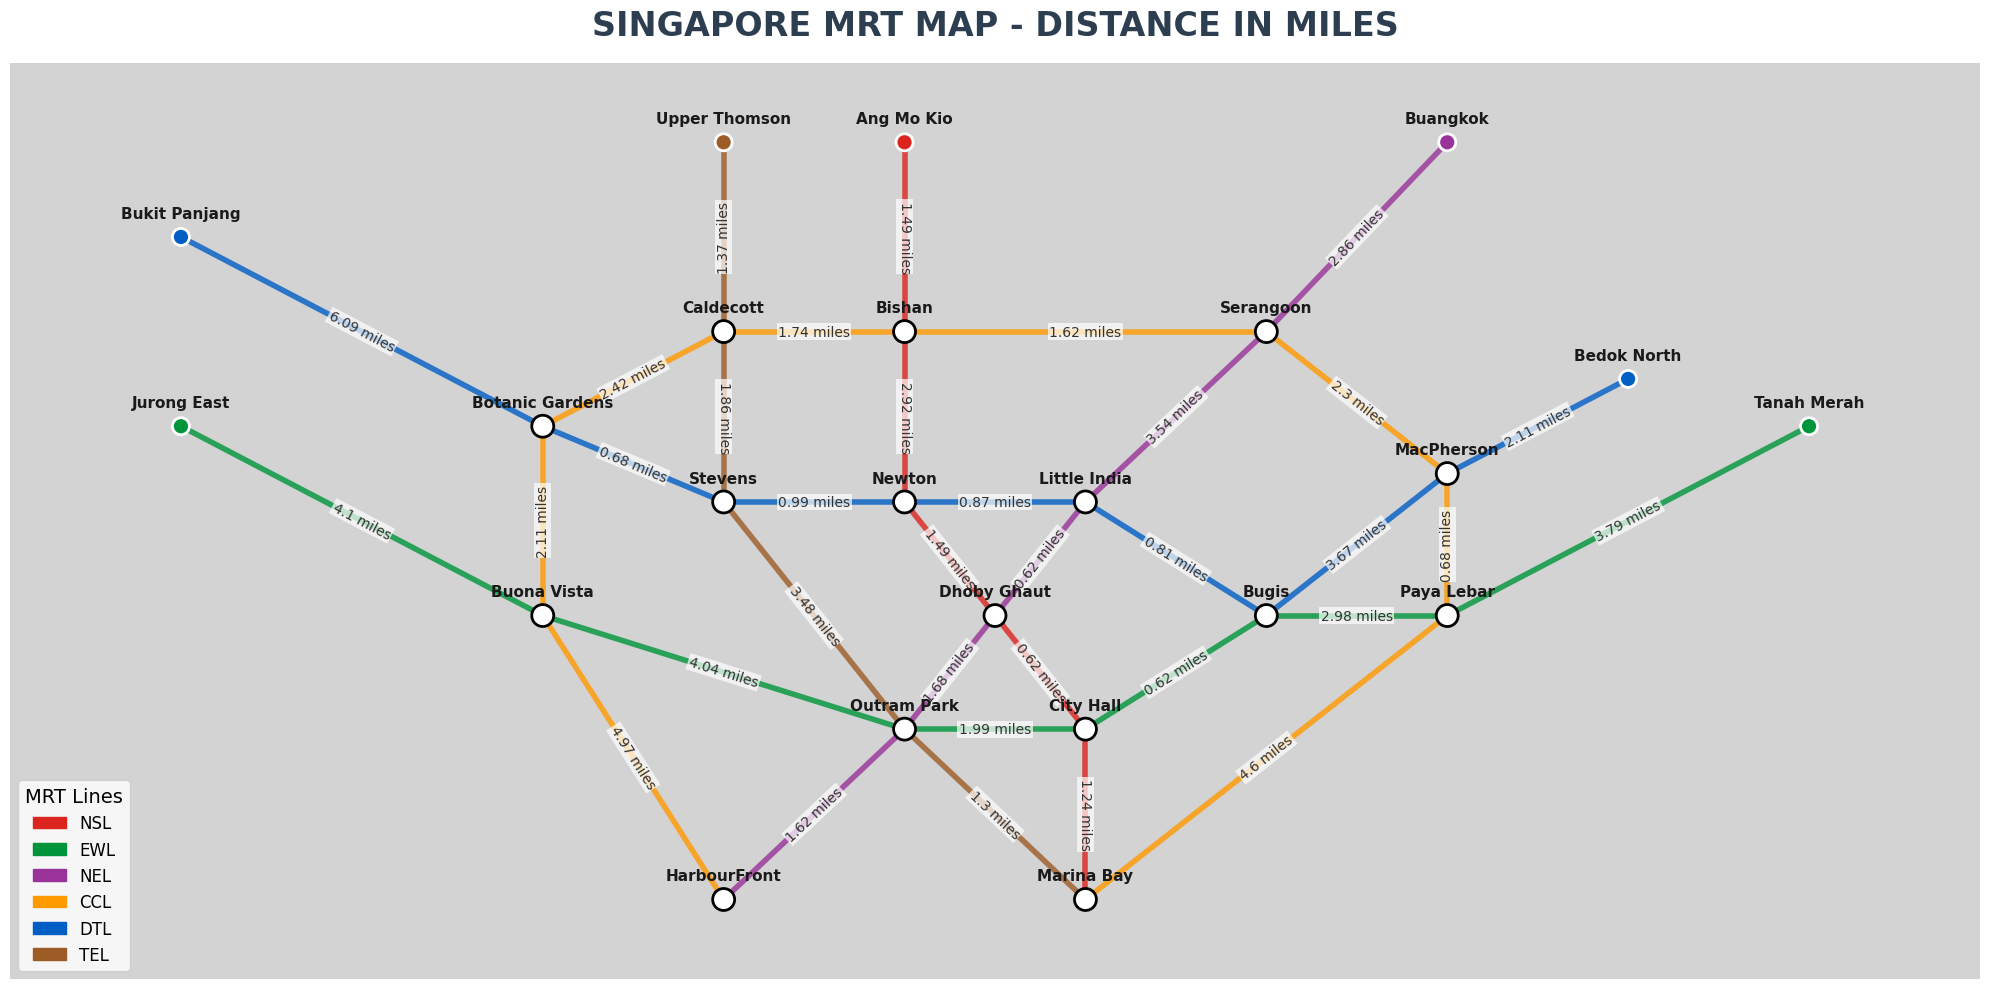


TASK 2: NETWORK DATA EXTRACTION RESULTS
1. Total length of the transport network:
   - 127.6 kilometers
   - 79.27 miles

2. Average distance between stations connected with single edge:
   - 3.65 kilometers
   - 2.26 miles



In [6]:
# --- TASK 1: VISUALIZATION OF SINGAPORE MRT NETWORK ---
def draw_beautiful_mrt_map():
    # --- USER CHOICE FOR UNIT ---
    print("Welcome to Singapore MRT Network Visualizer!")
    unit_choice = input("Do you want to display distances in 'km' or 'miles'? (Enter 'km' or 'miles'): ").strip().lower()
    
    # Handle invalid input, default to km
    if unit_choice not in ['km', 'miles']:
        print("Invalid choice. The map will display in 'km' by default.")
        unit_choice = 'km'

    G = nx.Graph()

    # 1. Standard LTA color codes
    colors = {
        'NSL': '#dc241f', 'EWL': '#00953b', 'NEL': '#993399',
        'CCL': '#ff9a00', 'DTL': '#005ec4', 'TEL': '#9d5b25'
    }

    # 2. Station coordinates
    pos = {
        'Jurong East': (2, 6), 'Upper Thomson': (5, 9), 'Ang Mo Kio': (6, 9), 
        'Bishan': (6, 7), 'Newton': (6, 5.2), 
        'Dhoby Ghaut': (6.5, 4), 'City Hall': (7.0, 2.8),
        'Marina Bay': (7, 1), 'Buona Vista': (4, 4),
        'Outram Park': (6, 2.8), 'Bugis': (8, 4), 
        'Paya Lebar': (9, 4), 'Tanah Merah': (11, 6),
        'Pasir Ris': (13, 7.5), 'HarbourFront': (5, 1),
        'Little India': (7, 5.2), 'Serangoon': (8, 7), 'Buangkok': (9, 9),
        'Botanic Gardens': (4, 6), 'Stevens': (5, 5.2), 
        'Caldecott': (5, 7), 'MacPherson': (9, 5.5), 
        'Bukit Panjang': (2, 8), 'Bedok North': (10, 6.5)
    }

    # 3. Line connections with weights (km)
    lines_edges = {
        'NSL': [('Ang Mo Kio','Bishan', 2.4), ('Bishan', 'Newton', 4.7), ('Newton', 'Dhoby Ghaut', 2.4), ('Dhoby Ghaut', 'City Hall', 1.0), ('City Hall', 'Marina Bay', 2.0)],
        'EWL': [('Jurong East', 'Buona Vista', 6.6), ('Buona Vista', 'Outram Park', 6.5), ('Outram Park', 'City Hall', 3.2), ('City Hall', 'Bugis', 1.0), ('Bugis', 'Paya Lebar', 4.8), ('Paya Lebar', 'Tanah Merah', 6.1)],
        'NEL': [('HarbourFront', 'Outram Park', 2.6), ('Outram Park','Dhoby Ghaut', 2.7), ('Dhoby Ghaut', 'Little India', 1.0), ('Little India', 'Serangoon', 5.7), ('Serangoon', 'Buangkok', 4.6)],
        'CCL': [('HarbourFront', 'Buona Vista', 8.0), ('Buona Vista', 'Botanic Gardens', 3.4), ('Botanic Gardens', 'Caldecott', 3.9), ('Caldecott', 'Bishan', 2.8), ('Bishan', 'Serangoon', 2.6), ('Serangoon', 'MacPherson', 3.7), ('MacPherson', 'Paya Lebar', 1.1), ('Paya Lebar', 'Marina Bay', 7.4)],
        'DTL': [('Bukit Panjang', 'Botanic Gardens', 9.8), ('Botanic Gardens', 'Stevens', 1.1), ('Stevens', 'Newton', 1.6), ('Newton', 'Little India', 1.4), ('Little India', 'Bugis', 1.3), ('Bugis', 'MacPherson', 5.9), ('MacPherson', 'Bedok North', 3.4)],
        'TEL': [('Upper Thomson', 'Caldecott', 2.2), ('Caldecott', 'Stevens', 3.0), ('Stevens', 'Outram Park', 5.6), ('Outram Park', 'Marina Bay', 2.1)]
    }

    # 4. ADD EDGE ATTRIBUTES AND DETERMINE NODE COLORS
    node_lines = {}
    for line, edges in lines_edges.items():
        for u, v, w_km in edges:
            # Calculate miles from km and round to 2 decimal places
            w_miles = round(w_km * 0.621371, 2)
            
            # Add edge with both attributes: km and miles
            G.add_edge(u, v, km=w_km, miles=w_miles)
            
            if u not in node_lines: node_lines[u] = set()
            if v not in node_lines: node_lines[v] = set()
            node_lines[u].add(line)
            node_lines[v].add(line)

    node_colors = []
    node_edge_colors = []
    node_sizes = []
    
    for node in G.nodes():
        lines_at_node = node_lines.get(node, set())
        if len(lines_at_node) > 1:
            node_colors.append('white')
            node_edge_colors.append('black')
            node_sizes.append(250)
        else:
            single_line = list(lines_at_node)[0]
            node_colors.append(colors[single_line])
            node_edge_colors.append('white')
            node_sizes.append(150)

    # --- SETUP INTERFACE ---
    fig, ax = plt.subplots(figsize=(20, 10)) 
    ax.set_aspect('auto') 
    ax.set_facecolor('lightgray') 
    ax.grid(False)

    # --- DRAW EDGES (LINES) ---
    for line, edges in lines_edges.items():
        edge_list = [(u, v) for u, v, w in edges]
        nx.draw_networkx_edges(G, pos, edgelist=edge_list, edge_color=colors[line], width=4, alpha=0.8, ax=ax)

    # --- DRAW WEIGHTS (Based on user choice) ---
    # Get the corresponding attribute ('km' or 'miles')
    edge_labels = nx.get_edge_attributes(G, unit_choice)
    # Format display string
    edge_labels_fmt = {k: f"{v} {unit_choice}" for k, v in edge_labels.items()}
    nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels_fmt, font_size=10, font_color='#333333', bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1), ax=ax)

    # --- DRAW NODES (STATIONS) ---
    nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=node_colors, edgecolors=node_edge_colors, linewidths=2, ax=ax)

    # --- DRAW LABELS ---
    label_pos = {k: (v[0], v[1] + 0.25) for k, v in pos.items()}
    nx.draw_networkx_labels(G, label_pos, font_size=11, font_weight='bold', font_color='#1a1a1a', ax=ax)

    # --- TITLE & AXES ---
    plt.title(f"SINGAPORE MRT MAP - DISTANCE IN {unit_choice.upper()}", fontsize=24, fontweight='bold', pad=20, color='#2c3e50')
    
    for spine in ax.spines.values():
        spine.set_visible(False)
    
    ax.tick_params(left=False, bottom=False, labelleft=False, labelbottom=False)

    # Add legend
    import matplotlib.patches as mpatches
    legend_elements = [mpatches.Patch(color=colors[line], label=line) for line in colors]
    ax.legend(handles=legend_elements, loc='lower left', title='MRT Lines', fontsize=12, title_fontsize=14)

    plt.tight_layout()
    plt.show()

    # --- TASK 2: DATA EXTRACTION & ANALYSIS ---

    print("\n" + "="*50)
    print("TASK 2: NETWORK DATA EXTRACTION RESULTS")
    print("="*50)
    
    total_km = 0
    total_miles = 0
    num_edges = G.number_of_edges()

    for u, v, data in G.edges(data=True):
        total_km += data['km']
        total_miles += data['miles']

    # calculate averages
    avg_km = total_km / num_edges if num_edges > 0 else 0
    avg_miles = total_miles / num_edges if num_edges > 0 else 0

    # output results
    print(f"1. Total length of the transport network:")
    print(f"   - {round(total_km, 2)} kilometers")
    print(f"   - {round(total_miles, 2)} miles\n")
    
    print(f"2. Average distance between stations connected with single edge:")
    print(f"   - {round(avg_km, 2)} kilometers")
    print(f"   - {round(avg_miles, 2)} miles")
    print("="*50 + "\n")

# Call the function to run the program
draw_beautiful_mrt_map()